# Análise de Inadimplência em Carteira de Crédito
## Etapa 1 — Coleta e Limpeza de Dados

**Dataset:** [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit) — Kaggle  
**Objetivo de negócio:** Entender o perfil de clientes inadimplentes para apoiar decisões de concessão de crédito.

---

### Contexto
Bancos e financeiras perdem bilhões anualmente com inadimplência. A capacidade de identificar, antes da concessão, quais clientes têm maior risco de não pagar é um dos problemas mais valiosos em ciência de dados aplicada a finanças.

Nesta etapa, vamos:
1. Carregar e inspecionar os dados brutos
2. Entender o significado de cada variável (dicionário de dados)
3. Identificar e tratar valores nulos
4. Detectar e tratar outliers
5. Salvar o dataset limpo para as próximas etapas

## 0. Setup e imports

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Carregamento dos dados

> **Como obter o dataset:** Acesse https://www.kaggle.com/c/GiveMeSomeCredit, faça o download de `cs-training.csv` e salve na mesma pasta deste notebook.

In [119]:
df = pd.read_csv('cs-training.csv', index_col=0)

print(f'Shape do dataset: {df.shape}')
print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}')

Shape do dataset: (150000, 11)
Linhas: 150,000 | Colunas: 11


In [120]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


## 2. Dicionário de dados

Antes de qualquer análise, é fundamental entender o que cada coluna representa. Em contextos reais de consultoria, esse mapeamento costuma vir do cliente ou de documentação técnica.

| Coluna | Descrição | Tipo |
|--------|-----------|------|
| `SeriousDlqin2yrs` | **Target** — cliente ficou 90+ dias inadimplente nos últimos 2 anos (1 = sim) | Binária |
| `RevolvingUtilizationOfUnsecuredLines` | Saldo total em cartões e linhas de crédito pessoal dividido pelo limite disponível (exclui imóveis e parcelas fixas) | Razão |
| `age` | Idade do cliente em anos | Inteira |
| `NumberOfTime60-89DaysPastDueNotWorse` | Nº de vezes que atrasou 60–89 dias sem agravar para faixas piores, nos últimos 2 anos | Inteira |
| `DebtRatio` | Pagamentos mensais de dívidas, pensão e custo de vida divididos pela renda bruta mensal | Razão |
| `MonthlyIncome` | Renda mensal em dólares | Contínua |
| `NumberOfOpenCreditLinesAndLoans` | Nº de linhas de crédito e empréstimos abertos | Inteira |
| `NumberOfTimes90DaysLate` | Nº de vezes com atraso de 90+ dias | Inteira |
| `NumberRealEstateLoansOrLines` | Nº de empréstimos imobiliários | Inteira |
| `NumberOfTime60-89DaysPastDueNotWorse` | Nº de vezes que atrasou 60–89 dias sem agravar para faixas piores, nos últimos 2 anos | Inteira |
| `NumberOfDependents` | Nº de dependentes na família | Inteira |

In [121]:
# Renomear colunas para facilitar o trabalho
colunas = {
    'SeriousDlqin2yrs': 'target',
    'RevolvingUtilizationOfUnsecuredLines': 'razao_utilizacao_rotativo',
    'age': 'idade',
    'NumberOfTime30-59DaysPastDueNotWorse': 'atrasos_30_59d_sem_agrav',
    'DebtRatio': 'razao_divida',
    'MonthlyIncome': 'renda_mensal',
    'NumberOfOpenCreditLinesAndLoans': 'linhas_credito_abertas',
    'NumberOfTimes90DaysLate': 'atrasos_90d',
    'NumberRealEstateLoansOrLines': 'emprestimos_imoveis',
    'NumberOfTime60-89DaysPastDueNotWorse': 'atrasos_60_89d_sem_agrav',
    'NumberOfDependents': 'dependentes'
}

df.rename(columns=colunas, inplace=True)
print('Colunas renomeadas:', df.columns.tolist())

Colunas renomeadas: ['target', 'razao_utilizacao_rotativo', 'idade', 'atrasos_30_59d_sem_agrav', 'razao_divida', 'renda_mensal', 'linhas_credito_abertas', 'atrasos_90d', 'emprestimos_imoveis', 'atrasos_60_89d_sem_agrav', 'dependentes']


## 3. Inspeção geral

In [122]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   target                     150000 non-null  int64  
 1   razao_utilizacao_rotativo  150000 non-null  float64
 2   idade                      150000 non-null  int64  
 3   atrasos_30_59d_sem_agrav   150000 non-null  int64  
 4   razao_divida               150000 non-null  float64
 5   renda_mensal               120269 non-null  float64
 6   linhas_credito_abertas     150000 non-null  int64  
 7   atrasos_90d                150000 non-null  int64  
 8   emprestimos_imoveis        150000 non-null  int64  
 9   atrasos_60_89d_sem_agrav   150000 non-null  int64  
 10  dependentes                146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


In [123]:
df.describe()

,target,razao_utilizacao_rotativo,idade,atrasos_30_59d_sem_agrav,razao_divida,renda_mensal,linhas_credito_abertas,atrasos_90d,emprestimos_imoveis,atrasos_60_89d_sem_agrav,dependentes
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [124]:
contagem_target = df['target'].value_counts()
pct_inadimplente = df['target'].mean() * 100
pct_adimplente   = 100 - pct_inadimplente

print('Distribuição do target:')
print(contagem_target)
print(f'\nAdimplentes:   {contagem_target[0]:,} ({pct_adimplente:.1f}%)')
print(f'Inadimplentes: {contagem_target[1]:,} ({pct_inadimplente:.1f}%)')
print(f'\n⚠ Dataset desbalanceado: proporção de ~{pct_adimplente/pct_inadimplente:.0f}:1 entre adimplentes e inadimplentes.')
print('Na modelagem usaremos class_weight="balanced" para compensar.')

Distribuição do target:
target
0    139974
1     10026
Name: count, dtype: int64

Adimplentes:   139,974 (93.3%)
Inadimplentes: 10,026 (6.7%)

⚠ Dataset desbalanceado: proporção de ~14:1 entre adimplentes e inadimplentes.
Na modelagem usaremos class_weight="balanced" para compensar.


## 4. Análise e tratamento de valores nulos

Dados nulos são comuns em datasets reais — clientes podem não informar a renda, sistemas legados podem ter falhas de preenchimento. A estratégia de tratamento impacta diretamente a qualidade do modelo.

In [125]:
# Visão geral dos nulos
nulos = pd.DataFrame({
    'total_nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos = nulos[nulos['total_nulos'] > 0].sort_values('pct_nulos', ascending=False)

print('Colunas com valores nulos:')
print(nulos)

Colunas com valores nulos:
              total_nulos  pct_nulos
renda_mensal        29731      19.82
dependentes          3924       2.62


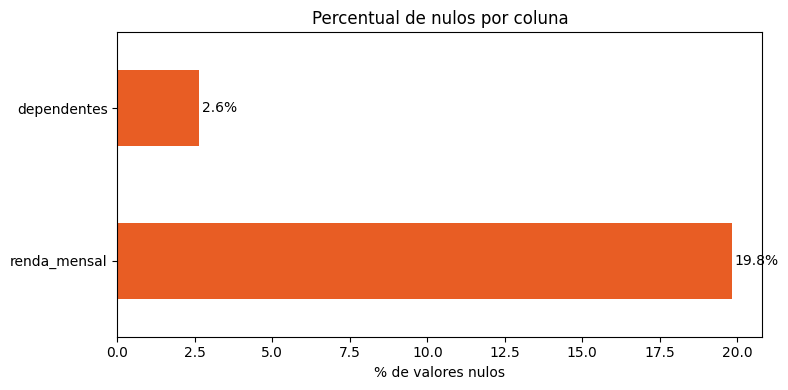

In [126]:
# Visualização dos nulos
fig, ax = plt.subplots(figsize=(8, 4))
nulos['pct_nulos'].plot(kind='barh', ax=ax, color='#E85D24')
ax.set_xlabel('% de valores nulos')
ax.set_title('Percentual de nulos por coluna')
for i, v in enumerate(nulos['pct_nulos']):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

In [127]:
# ------------------------------------------------------------------
# Tratamento: renda_mensal (~20% nulos)
# Estratégia: imputação pela MEDIANA — robusta a outliers.
# A média seria distorcida pelos valores extremos de renda.
# ------------------------------------------------------------------
mediana_renda = df['renda_mensal'].median()
df['renda_mensal'].fillna(mediana_renda, inplace=True)

# Criamos uma flag binária para preservar a informação de que era nulo
# Isso pode ser relevante para o modelo (clientes sem renda declarada)
df['renda_era_nula'] = (df['renda_mensal'] == mediana_renda).astype(int)

print(f'renda_mensal — mediana usada para imputação: R$ {mediana_renda:,.0f}')

renda_mensal — mediana usada para imputação: R$ 5,400


In [128]:
# ------------------------------------------------------------------
# Tratamento: dependentes (~2.6% nulos)
# Estratégia: imputação pela MODA (0 dependentes é o valor mais comum)
# ------------------------------------------------------------------
moda_dependentes = df['dependentes'].mode()[0]
df['dependentes'].fillna(moda_dependentes, inplace=True)

print(f'dependentes — moda usada: {moda_dependentes}')
print(f'\nNulos restantes: {df.isnull().sum().sum()}')

dependentes — moda usada: 0.0

Nulos restantes: 33655


## 5. Detecção e tratamento de outliers

Outliers podem ser erros de digitação, dados corrompidos ou valores legítimos mas extremos. É preciso investigar cada caso antes de remover ou transformar.

In [129]:
# Inspecionar os casos mais extremos
colunas_numericas = ['idade', 'razao_utilizacao_rotativo', 'razao_divida',
                     'renda_mensal', 'atrasos_30_59d_sem_agrav', 'atrasos_90d', 'atrasos_60_89d_sem_agrav']

for col in colunas_numericas:
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    vmin, vmax = df[col].min(), df[col].max()
    print(f'{col:<28} | min: {vmin:>12.2f} | p1: {p1:>10.2f} | p99: {p99:>10.2f} | max: {vmax:>12.2f}')

idade                        | min:         0.00 | p1:      24.00 | p99:      87.00 | max:       109.00
razao_utilizacao_rotativo    | min:         0.00 | p1:       0.00 | p99:       1.09 | max:     50708.00
razao_divida                 | min:         0.00 | p1:       0.00 | p99:    4979.04 | max:    329664.00
renda_mensal                 | min:         0.00 | p1:       0.00 | p99:   25000.00 | max:   3008750.00
atrasos_30_59d_sem_agrav     | min:         0.00 | p1:       0.00 | p99:       4.00 | max:        98.00
atrasos_90d                  | min:         0.00 | p1:       0.00 | p99:       3.00 | max:        98.00
atrasos_60_89d_sem_agrav     | min:         0.00 | p1:       0.00 | p99:       2.00 | max:        98.00


In [130]:
# ------------------------------------------------------------------
# Problema 1: idade — existem clientes com idade 0
# Claramente um erro de preenchimento. Removemos essas linhas.
# ------------------------------------------------------------------
antes = len(df)
df = df[df['idade'] > 0]
print(f'Linhas removidas por idade == 0: {antes - len(df)}')

Linhas removidas por idade == 0: 1


In [131]:
# ------------------------------------------------------------------
# Problema 2: uso_credito_rotativo — valores acima de 1 (100%)
# Tecnicamente possível (acima do limite), mas valores > 10 são suspeitos.
# Estratégia: capping no percentil 99 (winsorização)
# ------------------------------------------------------------------
cap_uso = df['razao_utilizacao_rotativo'].quantile(0.99)
df['razao_utilizacao_rotativo'] = df['razao_utilizacao_rotativo'].clip(upper=cap_uso)
print(f'razao_utilizacao_rotativo — capped em: {cap_uso:.4f}')

razao_utilizacao_rotativo — capped em: 1.0930


In [132]:
# ------------------------------------------------------------------
# Problema 3: razao_divida — valores absurdamente altos (> 1 milhão)
# Estratégia: capping no percentil 99
# ------------------------------------------------------------------
cap_divida = df['razao_divida'].quantile(0.99)
df['razao_divida'] = df['razao_divida'].clip(upper=cap_divida)
print(f'razao_divida — capped em: {cap_divida:.2f}')

razao_divida — capped em: 4979.08


In [133]:
# ------------------------------------------------------------------
# Problema 4: colunas de atrasos com valor 96 e 98 (códigos especiais)
# Esses valores provavelmente representam categorias especiais (erro/ausência)
# e não atrasos reais. Vamos substituir por NaN e depois pela mediana.
# ------------------------------------------------------------------
colunas_atraso = ['atrasos_30_59d_sem_agrav', 'atrasos_60_89d_sem_agrav', 'atrasos_90d']

for col in colunas_atraso:
    mask = df[col].isin([96, 98])
    n = mask.sum()
    if n > 0:
        mediana = df.loc[~mask, col].median()
        df.loc[mask, col] = mediana
        print(f'{col}: {n} valores 96/98 substituídos pela mediana ({mediana:.1f})')

atrasos_30_59d_sem_agrav: 269 valores 96/98 substituídos pela mediana (0.0)
atrasos_60_89d_sem_agrav: 269 valores 96/98 substituídos pela mediana (0.0)
atrasos_90d: 269 valores 96/98 substituídos pela mediana (0.0)


In [134]:
# ------------------------------------------------------------------
# Problema 5: renda_mensal — valores muito altos
# Estratégia: capping no percentil 99.5 para manter alguma variação
# ------------------------------------------------------------------
cap_renda = df['renda_mensal'].quantile(0.995)
df['renda_mensal'] = df['renda_mensal'].clip(upper=cap_renda)
print(f'renda_mensal — capped em: ${cap_renda:,.0f}')

renda_mensal — capped em: $35,000


## 6. Criação de features derivadas

In [135]:
# Total de atrasos (qualquer faixa)
df['total_atrasos'] = df['atrasos_30_59d_sem_agrav'] + df['atrasos_60_89d_sem_agrav'] + df['atrasos_90d']

# Flag: cliente tem algum histórico de atraso
df['tem_historico_atraso'] = (df['total_atrasos'] > 0).astype(int)

# Faixa etária — variável categórica ordinal
bins = [0, 25, 35, 45, 55, 65, 120]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels)

# Encargos mensais estimados (razao_divida × renda)
# Cuidado: onde renda era nula, esse valor pode ser pouco confiável
df['encargos_mensais_estimados'] = df['razao_divida'] * df['renda_mensal']

print('Features derivadas criadas:')
print(['total_atrasos', 'tem_historico_atraso', 'faixa_etaria', 'encargos_mensais_estimados'])

Features derivadas criadas:
['total_atrasos', 'tem_historico_atraso', 'faixa_etaria', 'encargos_mensais_estimados']


## 7. Verificação final e salvamento

In [136]:
print('=== RESUMO DA LIMPEZA ===')
print(f'Shape final:          {df.shape}')
print(f'Nulos restantes:      {df.isnull().sum().sum()}')
print(f'Inadimplentes:        {df["target"].sum():,} ({df["target"].mean()*100:.1f}%)')
print(f'Adimplentes:          {(df["target"]==0).sum():,} ({(df["target"]==0).mean()*100:.1f}%)')
print()
print('Colunas finais:', df.columns.tolist())

=== RESUMO DA LIMPEZA ===
Shape final:          (149999, 16)
Nulos restantes:      63386
Inadimplentes:        10,026 (6.7%)
Adimplentes:          139,973 (93.3%)

Colunas finais: ['target', 'razao_utilizacao_rotativo', 'idade', 'atrasos_30_59d_sem_agrav', 'razao_divida', 'renda_mensal', 'linhas_credito_abertas', 'atrasos_90d', 'emprestimos_imoveis', 'atrasos_60_89d_sem_agrav', 'dependentes', 'renda_era_nula', 'total_atrasos', 'tem_historico_atraso', 'faixa_etaria', 'encargos_mensais_estimados']


In [137]:
# Verificar tipos de dados
df.dtypes

target                           int64
razao_utilizacao_rotativo      float64
idade                            int64
atrasos_30_59d_sem_agrav         int64
razao_divida                   float64
renda_mensal                   float64
linhas_credito_abertas           int64
atrasos_90d                      int64
emprestimos_imoveis              int64
atrasos_60_89d_sem_agrav         int64
dependentes                    float64
renda_era_nula                   int64
total_atrasos                    int64
tem_historico_atraso             int64
faixa_etaria                  category
encargos_mensais_estimados     float64
dtype: object

In [138]:
# Salvar dataset limpo
df.to_csv('dados_limpos.csv', index=False)
print('✓ Dataset salvo em dados_limpos.csv')
print('  Pronto para a Etapa 2 — Análise Exploratória (EDA)')

✓ Dataset salvo em dados_limpos.csv
  Pronto para a Etapa 2 — Análise Exploratória (EDA)


---

## Resumo das decisões tomadas

| Problema | Coluna | Estratégia | Justificativa |
|----------|--------|------------|---------------|
| ~20% nulos | `renda_mensal` | Mediana + flag | Mediana é robusta a outliers de renda |
| ~2.6% nulos | `dependentes` | Moda (0) | Distribuição fortemente concentrada em 0 |
| Erros de cadastro | `idade == 0` | Remoção | Não é possível ter 0 anos como cliente |
| Valores extremos | `uso_credito_rotativo`, `razao_divida`, `renda_mensal` | Winsorização (p99) | Preserva a distribuição, reduz influência dos extremos |
| Códigos especiais | Colunas de atraso | Substituição pela mediana | Valores 96/98 não representam atrasos reais |

> **Nota:** Todas as decisões de limpeza devem ser documentadas e justificadas. Em um projeto real de consultoria, essas escolhas seriam validadas com o cliente antes de prosseguir.